## Mini Project # 2
**Student Name:** Farzeen Mahmood Farooqi
**Course:** GIS Projects and Programming 
**Instructor:** Eric Kerney
**University:** Western Michigan University  
**Date:** 6th April 2026

# Project 2: Raster and Vector Geospatial Analysis with Google Earth Engine and DuckDB

## Topic
**Summer heat and rainfall patterns in California**

## Goal
This notebook combines:
- **2 raster layers from Google Earth Engine**
- **2 vector layers stored in DuckDB**

The project explores how summer temperature and precipitation patterns relate to county boundaries and river locations in California.

## Why this project fits the assignment
- It uses **Google Earth Engine** for imagery/raster analysis
- It uses **DuckDB** as the database
- It includes **at least 2 EE layers** and **at least 2 database layers**


## Step 0: Install packages

I did this in the VS code and downloaded the necessary pacakges for my project.


## Step 1: Import libraries

In [24]:
import ee
import geemap
import duckdb
import geopandas as gpd
import pandas as pd

## Step 1: Import Libraries

In this step, I imported all the libraries needed for the project.  

I used Earth Engine to get raster data, Geemap to create maps, DuckDB for database storage, GeoPandas for spatial data, and Pandas for data analysis.  

These libraries help me process, analyze, and visualize geospatial data.

## Step 2: Authenticate and initialize Earth Engine


In [25]:
import ee 
ee.Authenticate()
ee.Initialize(project='mini-project-2-492523')

##  Explanation

In this step, I connected my project to Google Earth Engine. First, I ran the authentication process and signed in with my Google account. Then, I copied and pasted the authorization code to give access. After that, I initialized Earth Engine using my project ID. This step is important because it allows me to access and use satellite and raster data from Google Earth Engine in my project.

## Step 3: Load boundary data for California

This notebook uses public vector data:
- **US Census TIGER/Line states**
- **US Census TIGER/Line counties**
- **Natural Earth rivers**



In [26]:
import geopandas as gpd

In [27]:
states_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
counties_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
rivers_url = "https://naciscdn.org/naturalearth/10m/physical/ne_10m_rivers_lake_centerlines.zip"

states = gpd.read_file(states_url)
counties_all = gpd.read_file(counties_url)
rivers_all = gpd.read_file(rivers_url)

california = states[states["NAME"] == "California"].copy()
counties = counties_all[counties_all["STATEFP"] == "06"].copy()

rivers_all = rivers_all.to_crs(california.crs)
rivers = gpd.clip(rivers_all, california)

print("California polygons:", len(california))
print("California counties:", len(counties))
print("California river features after clip:", len(rivers))

California polygons: 1
California counties: 58
California river features after clip: 16


## Step 3: Load Boundary Data for California

In this step, I loaded vector data for California using GeoPandas from public data sources.

The data sources used are:

- US Census Bureau (2023 Cartographic Boundary Files - States & Counties):  
  https://www.census.gov/geographies/mapping-files/time-series/geo/cartographic-boundary.2023.html  

- Natural Earth (Rivers dataset):  
  https://www.naturalearthdata.com/downloads/10m-physical-vectors/  

The US Census 2023 dataset provides boundary data for states and counties, and Natural Earth provides global river data.

First, I read the datasets directly from these sources using GeoPandas. Then, I selected only California from the states dataset and filtered the counties that belong to California. After that, I ensured that the coordinate systems matched and clipped the river dataset so that only rivers within California were included.

Since the river dataset is global, this clipping step was necessary to extract only the rivers located in California.

Finally, I checked the number of polygons, counties, and river features to confirm that the data was loaded and processed correctly.

## Role of Rivers in the Analysis

In this project, rivers are used as supporting data to help understand spatial patterns.

Rivers do not directly affect temperature or precipitation, but they provide useful information about water distribution across California.

Areas with more rivers generally indicate regions that receive more rainfall or have better water availability, while areas with fewer rivers tend to be drier.

By comparing rivers with temperature and precipitation layers, it becomes easier to identify patterns such as wet regions in the north and dry regions in the south.

Therefore, rivers help support the interpretation of summer heat and rainfall patterns without being a direct cause of climate conditions.

## Step 4: Create and populate DuckDB


In [28]:
import duckdb

In [29]:
con = duckdb.connect("project2.duckdb")

counties_db = counties[["NAME", "STATEFP", "GEOID", "geometry"]].copy()
counties_db["wkt"] = counties_db.geometry.to_wkt()
counties_db = counties_db.drop(columns="geometry")

river_name_col = "name" if "name" in rivers.columns else None
if river_name_col:
    rivers_db = rivers[[river_name_col, "featurecla", "geometry"]].copy()
    rivers_db = rivers_db.rename(columns={river_name_col: "river_name"})
else:
    rivers_db = rivers[["featurecla", "geometry"]].copy()
    rivers_db["river_name"] = None
    rivers_db = rivers_db[["river_name", "featurecla", "geometry"]]

rivers_db["wkt"] = rivers_db.geometry.to_wkt()
rivers_db = rivers_db.drop(columns="geometry")

con.register("counties_temp", counties_db)
con.register("rivers_temp", rivers_db)

con.execute("CREATE OR REPLACE TABLE counties AS SELECT * FROM counties_temp")
con.execute("CREATE OR REPLACE TABLE rivers AS SELECT * FROM rivers_temp")

con.execute("SHOW TABLES").fetchdf()

,name
0,counties
1,counties_temp
2,rivers
3,rivers_temp


## Explanation
In this step, I created a DuckDB database to store my spatial data.

First, I connected to a DuckDB database file. Then, I selected important columns from the California counties and rivers datasets.

Since DuckDB does not directly store geometry data, I converted the geometry into WKT (Well-Known Text) format. After that, I removed the original geometry column.

Next, I registered the data as temporary tables and created permanent tables for counties and rivers inside the database.

Finally, I checked that the tables were created successfully. This step helps store and manage the spatial data efficiently for further analysis.

## Step 5: Query the database

In [30]:
county_preview = con.execute("SELECT NAME, GEOID FROM counties ORDER BY NAME LIMIT 10").fetchdf()
river_preview = con.execute("SELECT river_name, featurecla FROM rivers LIMIT 10").fetchdf()

print("County preview")
display(county_preview)

print("River preview")
display(river_preview)

County preview


,NAME,GEOID
0,Alameda,06001
1,Alpine,06003
2,Amador,06005
3,Butte,06007
4,Calaveras,06009
5,Colusa,06011
6,Contra Costa,06013
7,Del Norte,06015
8,El Dorado,06017
9,Fresno,06019


River preview


,river_name,featurecla
0,Salinas,River
1,Colorado,River
2,Salinas,River
3,San Joaquin,Lake Centerline
4,San Joaquin,River
5,Stanislaus,River
6,Feather,River
7,None,River
8,Feather,Lake Centerline
9,Sacramento,River


In [31]:
import pandas as pd

In [32]:
summary_counts = pd.DataFrame({
    "Layer": ["California counties", "California rivers"],
    "Feature count": [
        con.execute("SELECT COUNT(*) FROM counties").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM rivers").fetchone()[0]
    ]
})
summary_counts

,Layer,Feature count
0,California counties,58
1,California rivers,16


## Explanation

In this step, I queried the DuckDB database to view and check the stored data.

First, I selected a few rows from the counties and rivers tables to preview the data. This helped me make sure that the data was stored correctly.

Then, I counted the total number of counties and rivers in the database. I created a small summary table to show these counts.

This step helped me verify that the database was working properly and that the data was ready for further analysis.

## Step 6: Rebuild GeoDataFrames from DuckDB tables

This is useful because the assignment asks for layers brought in from a database.  
Here we read the tables back from DuckDB and convert the WKT text back into geometry.

In [33]:
counties_from_db = con.execute("SELECT NAME, STATEFP, GEOID, wkt FROM counties").fetchdf()
counties_from_db = gpd.GeoDataFrame(
    counties_from_db.drop(columns="wkt"),
    geometry=gpd.GeoSeries.from_wkt(counties_from_db["wkt"]),
    crs=counties.crs
)

rivers_from_db = con.execute("SELECT river_name, featurecla, wkt FROM rivers").fetchdf()
rivers_from_db = gpd.GeoDataFrame(
    rivers_from_db.drop(columns="wkt"),
    geometry=gpd.GeoSeries.from_wkt(rivers_from_db["wkt"]),
    crs=rivers.crs
)

print(counties_from_db.head())
print(rivers_from_db.head())

            NAME STATEFP  GEOID  \
0  San Francisco      06  06075   
1         Sierra      06  06091   
2         Merced      06  06047   
3      Del Norte      06  06015   
4         Orange      06  06059   

                                            geometry  
0  POLYGON ((-122.51198 37.77113, -122.4654 37.80...  
1  POLYGON ((-121.0582 39.53704, -121.00948 39.63...  
2  POLYGON ((-121.2268 37.13477, -120.96381 37.34...  
3  POLYGON ((-124.21959 41.84643, -124.2034 41.94...  
4  POLYGON ((-118.09303 33.78612, -118.05904 33.8...  
    river_name       featurecla  \
0      Salinas            River   
1     Colorado            River   
2      Salinas            River   
3  San Joaquin  Lake Centerline   
4  San Joaquin            River   

                                            geometry  
0  LINESTRING (-120.88884 36.00002, -120.85425 35...  
1  MULTILINESTRING ((-114.52126 34.75689, -114.52...  
2  LINESTRING (-120.88892 36.00002, -120.9104 36....  
3  LINESTRING (-119.60083 37

## Explanation

In this step, I read the counties and rivers data back from the DuckDB database.

The geometry was stored as WKT (text format), so I converted it back into real geometry using GeoPandas. This allowed me to rebuild the data into GeoDataFrames.

After that, I printed a few rows to check that the data was correctly converted.

This step is important because it prepares the data for mapping and further spatial analysis.

## Step 7: Define the California area of interest in Earth Engine

In [34]:
import geemap

In [35]:
california_ee = geemap.geopandas_to_ee(california)

## Explanation

In this step, I converted the California boundary data from GeoPandas format into Google Earth Engine format using Geemap.

This is important because Earth Engine cannot directly use GeoPandas data. So, I changed the format so that Earth Engine can understand it.

After this, I can use the California area to apply temperature and rainfall data only within this region.

This step helps me focus my analysis specifically on California.

## Step 8: Load raster data from Google Earth Engine

We use the official **GRIDMET** dataset and select two bands:
- `tmmx` = maximum temperature
- `pr` = precipitation

We use **summer 2023** as the analysis period.

In [36]:
start_date = "2023-06-01"
end_date = "2023-08-31"

gridmet = ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")

tmmx = (
    gridmet
    .filterDate(start_date, end_date)
    .select("tmmx")
    .mean()
    .clip(california_ee)
)

pr = (
    gridmet
    .filterDate(start_date, end_date)
    .select("pr")
    .sum()
    .clip(california_ee)
)

## Explanation

In this step, I loaded climate data from Google Earth Engine using the GRIDMET dataset.

I selected two important variables:
- `tmmx` for maximum temperature
- `pr` for precipitation (rainfall)

I focused on summer 2023, from June to August.

First, I filtered the dataset by date. Then, I calculated:
- the average temperature over the summer
- the total precipitation over the summer

Finally, I clipped both datasets to the California area so that the analysis only covers California.

This step is important because it gives me the main data (temperature and rainfall) needed for my analysis.

## Step 9: Visualization settings

In [37]:
tmmx_vis = {
    "min": 290,
    "max": 320,
    "palette": ["blue", "cyan", "green", "yellow", "orange", "red"]
}

pr_vis = {
    "min": 0,
    "max": 80,
    "palette": ["white", "lightblue", "blue", "darkblue"]
}

## Explanation
In this step, I defined how the temperature and precipitation data will look on the map.

For temperature (`tmmx_vis`), I set a minimum and maximum value and used a color palette from blue (cool) to red (hot). This helps show temperature differences clearly.

For precipitation (`pr_vis`), I also set a minimum and maximum value and used shades of blue, where lighter colors show less rainfall and darker colors show more rainfall.

These settings help make the map easier to understand by using colors to represent different values.

## Step 10: Create the interactive map

Layers included:
- Raster 1: GRIDMET maximum temperature
- Raster 2: GRIDMET precipitation
- Vector 1 from DuckDB: California counties
- Vector 2 from DuckDB: California rivers

In [38]:
Map = geemap.Map(center=[37.5, -119.5], zoom=6)

Map.addLayer(tmmx, tmmx_vis, "GRIDMET Max Temp (Summer Mean)")
Map.addLayer(pr, pr_vis, "GRIDMET Precipitation (Summer Total)")

Map.add_gdf(counties_from_db, layer_name="California Counties (DuckDB)")
Map.add_gdf(rivers_from_db, layer_name="California Rivers (DuckDB)")

import ipywidgets as widgets

legend_dict = {
    "Cool (Low Temp)": "blue",
    "Moderate": "yellow",
    "Hot (High Temp)": "red"
}

Map.add_layer_control()
Map.add_legend(title="Temperature (°C)", legend_dict=legend_dict)

Map.add_marker(
    location=[36.77, -119.41],
    popup=widgets.HTML(value="Central Valley")
)

# Map.to_html("california_map_final.html")

Map

Map(center=[37.5, -119.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## Explanation

In this step, I created an interactive map using Geemap.

First, I set the map center to California and adjusted the zoom level so the whole state is visible.

Then, I added two raster layers:
- maximum temperature (summer average)
- precipitation (summer total)

After that, I added two vector layers from DuckDB:
- California counties
- California rivers

I also added a layer control so I can turn layers on and off to explore the data.

Next, I created a legend to show temperature levels using colors:
- blue = cool
- yellow = moderate
- red = hot

I also added a marker on Central Valley to highlight an important location.

Finally, the map was displayed.


### Interpretation of Results

From the map, I can see clear patterns of temperature and rainfall across California.

The **Central Valley and southern parts** show **high temperatures (yellow to red colors)**, which means these areas are hotter during summer.

The **coastal areas and northern regions** show **cooler temperatures (blue colors)** because they are closer to the ocean or have higher elevation.

When looking at precipitation, most of California shows **low rainfall in summer**, which explains why many areas appear dry.

The **rivers are mainly located in areas where water is available**, especially flowing from higher elevation regions to lower areas.

This shows that even though California has some rivers, large parts of the state still experience **hot and dry summer conditions**.

The Central Valley marker helps highlight an important region that is **hot and dry but still important for agriculture**, which depends on water from rivers.

To clearly see temperature colors, I turned off the SRTM elevation layer from the layer control.

## Step 11: Terrain/Elevation


In [39]:
#SRTM elevation
srtm = ee.Image("USGS/SRTMGL1_003").clip(california_ee)
srtm_vis = {"min": 0, "max": 3500}

Map.addLayer(srtm, srtm_vis, "SRTM Elevation")
Map

Map(center=[np.float64(37.362656), np.float64(-119.2226955)], controls=(WidgetControl(options=['position', 'tr…

## Explanation

In this step, I added elevation (terrain) data to the map using the SRTM dataset from Google Earth Engine.

I clipped the elevation data to the California area so that only California is shown.

Then, I set the visualization range from 0 to 3500 meters.

Finally, I added this elevation layer to the map.



### Interpretation of Results

From the map, I can see the elevation differences across California.

The darker areas represent lower land, while the lighter areas represent higher elevation such as mountains.

The central part of California (Central Valley) appears darker, which means it is a low-lying area.

The eastern and northern parts show lighter colors, which means these areas have higher elevation, like mountain ranges.

This helps explain the temperature patterns:
- Higher elevation areas are usually cooler
- Lower elevation areas are usually hotter

It also helps explain water flow, as rivers usually start from higher elevation areas and flow down to lower regions.

Overall, elevation plays an important role in understanding temperature and rainfall patterns in California.

## Step 12: Simple database summaries

In [40]:
county_count = con.execute("SELECT COUNT(*) AS n_counties FROM counties").fetchdf()
river_count = con.execute("SELECT COUNT(*) AS n_river_features FROM rivers").fetchdf()

display(county_count)
display(river_count)

,n_counties
0,58


,n_river_features
0,16


In [41]:
county_letter_summary = con.execute(
    """
    SELECT SUBSTR(NAME, 1, 1) AS first_letter, COUNT(*) AS county_count
    FROM counties
    GROUP BY 1
    ORDER BY county_count DESC, first_letter
    """
).fetchdf()

county_letter_summary.head(10)

,first_letter,county_count
0,S,18
1,M,8
2,T,4
3,A,3
4,C,3
5,L,3
6,I,2
7,K,2
8,N,2
9,P,2


## Explanation

In this step, I used SQL queries to summarize the data stored in DuckDB.

First, I counted the total number of counties in the dataset using a SQL query.  
The result shows that there are **58 counties**.

Then, I counted the total number of river features.  
The result shows that there are **16 river features**.

After that, I created another summary based on the first letter of county names.

I extracted the first letter from each county name and grouped the data by that letter.  
Then, I counted how many counties start with each letter.

Finally, I sorted the results in descending order so that the letters with the highest counts appear first.

This step helps to quickly summarize and explore the data stored in the database.

## Step 13: Sample raster summary by county

The cell below calculates average summer temperature and total precipitation by county using Earth Engine.  


In [42]:
counties_ee = geemap.geopandas_to_ee(counties_from_db)

combined = tmmx.addBands(pr).rename(["tmmx_mean", "pr_total"])

county_stats_fc = combined.reduceRegions(
    collection=counties_ee,
    reducer=ee.Reducer.mean(),
    scale=4000
)

county_stats = geemap.ee_to_df(county_stats_fc)
county_stats.head()

,GEOID,NAME,STATEFP,pr_total,tmmx_mean
0,06075,San Francisco,06,0.473659,292.448407
1,06091,Sierra,06,53.428380,298.544777
2,06047,Merced,06,1.982674,306.779507
3,06015,Del Norte,06,14.348377,298.199986
4,06059,Orange,06,68.373802,299.203324


In [43]:
cols_to_keep = [c for c in ["NAME", "GEOID", "tmmx_mean", "pr_total"] if c in county_stats.columns]
county_stats_clean = county_stats[cols_to_keep].copy()

if "tmmx_mean" in county_stats_clean.columns:
    county_stats_clean["tmmx_celsius_approx"] = county_stats_clean["tmmx_mean"] - 273.15

county_stats_clean = county_stats_clean.sort_values(
    by=[c for c in ["tmmx_mean"] if c in county_stats_clean.columns],
    ascending=False
)

county_stats_clean.head(10)

,NAME,GEOID,tmmx_mean,pr_total,tmmx_celsius_approx
37,Imperial,06025,313.510113,46.547388,40.360113
33,Riverside,06065,309.107105,69.419336,35.957105
39,San Bernardino,06071,308.687256,68.156284,35.537256
41,Kings,06031,308.404977,10.980933,35.254977
6,Sutter,06101,306.905957,3.286543,33.755957
2,Merced,06047,306.779507,1.982674,33.629507
54,Colusa,06011,306.518393,4.510220,33.368393
21,Yolo,06113,306.464382,0.234214,33.314382
5,Stanislaus,06099,305.929668,0.676123,32.779668
10,Yuba,06115,305.914380,8.474140,32.764380


## Explanation

In this step, I calculated temperature and rainfall values for each county.

First, I converted the counties data into Earth Engine format so it can be used with raster data.

Then, I combined two raster datasets:
- maximum temperature (tmmx)
- precipitation (pr)

I renamed them to:
- tmmx_mean (average temperature)
- pr_total (total precipitation)

After that, I calculated the average values for each county using a function that summarizes raster data inside each county boundary.

This produced:
- average summer temperature for each county
- total summer precipitation for each county

Then, I converted the results into a table (DataFrame) to make it easier to view and analyze.

Next, I selected only important columns:
- county name
- GEOID
- temperature
- precipitation

I also converted temperature from Kelvin to Celsius for easier understanding.

Finally, I sorted the data in descending order based on temperature, so the hottest counties appear first.

This step helps to compare temperature and rainfall across different counties in a structured way.

## Step 14: A simple "hot and dry" ranking

This is an exploratory ranking analysis to go more in depth to explore more.

In [44]:
ranking_df = county_stats_clean.copy()

if {"tmmx_mean", "pr_total"}.issubset(ranking_df.columns):
    ranking_df["temp_rank"] = ranking_df["tmmx_mean"].rank(ascending=False)
    ranking_df["dry_rank"] = ranking_df["pr_total"].rank(ascending=True)
    ranking_df["hot_dry_score"] = ranking_df["temp_rank"] + ranking_df["dry_rank"]
    ranking_df = ranking_df.sort_values("hot_dry_score")

ranking_df.head(10)

,NAME,GEOID,tmmx_mean,pr_total,tmmx_celsius_approx,temp_rank,dry_rank,hot_dry_score
21,Yolo,06113,306.464382,0.234214,33.314382,8.0,5.0,13.0
35,San Joaquin,06077,305.850189,0.170762,32.700189,11.0,4.0,15.0
5,Stanislaus,06099,305.929668,0.676123,32.779668,9.0,9.0,18.0
6,Sutter,06101,306.905957,3.286543,33.755957,5.0,14.0,19.0
2,Merced,06047,306.779507,1.982674,33.629507,6.0,13.0,19.0
49,Solano,06095,304.121297,0.034123,30.971297,18.0,2.0,20.0
55,Sacramento,06067,305.388330,0.595532,32.238330,14.0,8.0,22.0
54,Colusa,06011,306.518393,4.510220,33.368393,7.0,17.0,24.0
9,Napa,06055,303.489394,0.400126,30.339394,22.0,6.0,28.0
41,Kings,06031,308.404977,10.980933,35.254977,4.0,24.0,28.0


<function matplotlib.pyplot.show(close=None, block=None)>

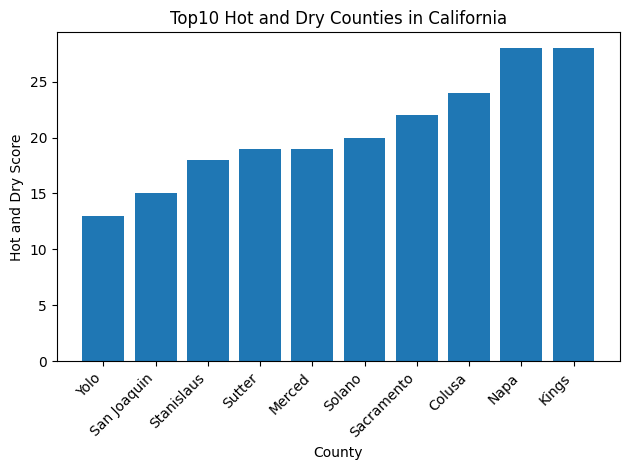

In [45]:
import matplotlib.pyplot as plt
top10 = ranking_df.head(10).copy()
plt.bar(top10["NAME"], top10["hot_dry_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Hot and Dry Score")
plt.xlabel("County")
plt.title("Top10 Hot and Dry Counties in California")
plt.tight_layout()
plt.show

## Explanation

In this step, I created a simple ranking to find counties that are both hot and dry.

First, I made a copy of the cleaned dataset.

Then, I created two rankings:
- **temp_rank** → ranks counties based on temperature (higher temperature = higher rank)
- **dry_rank** → ranks counties based on precipitation (lower rainfall = higher rank)

After that, I added both rankings together to create a new score called:
- **hot_dry_score**

This score helps identify counties that are both hot and dry.

Then, I sorted the dataset based on this score, so the most hot and dry counties appear at the top.

Finally, I selected the top 10 counties and created a bar chart to visualize the results.



### Interpretation of Results

The results show the counties that are relatively hotter and drier during summer.

From the table and chart:
- **Yolo** has the lowest score, meaning it is the most hot and dry among the listed counties.
- Other counties like **San Joaquin, Stanislaus, and Sutter** also show high hot and dry conditions.
- Counties like **Napa and Kings** have higher scores, meaning they are less extreme compared to the others in this top 10.

Overall:
- Lower score = more hot and dry
- Higher score = less hot and/or less dry

This analysis helps identify regions that may be more prone to heat and dryness during summer, which is useful for environmental and climate studies.

,County,Avg Summer Temp (°C),Class,Total Precipitation
0,Imperial,40.360113,Hot,46.547388
1,Riverside,35.957105,Hot,69.419336
2,San Bernardino,35.537256,Hot,68.156284
3,Kings,35.254977,Hot,10.980933
4,Sutter,33.755957,Hot,3.286543
5,Marin,24.203025,Cool,0.790312
6,San Mateo,23.063873,Cool,6.234939
7,Mono,22.304659,Cool,76.862456
8,Alpine,20.689863,Cool,78.930912
9,San Francisco,19.298407,Cool,0.473659


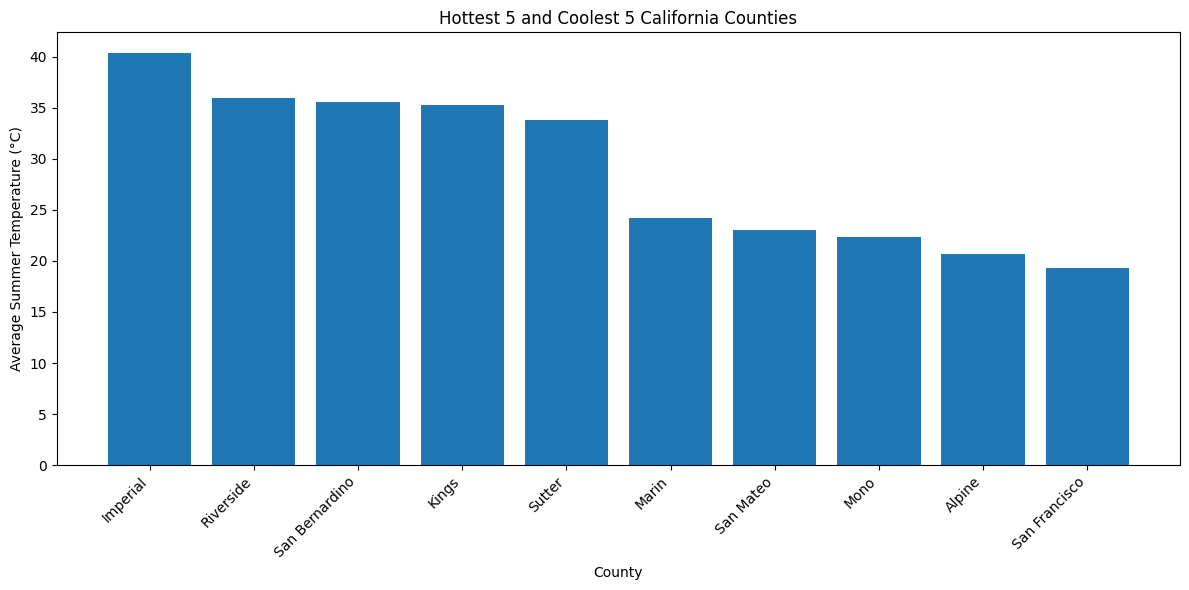

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Made a clean copy sorted by temperature
temp_df = county_stats_clean.copy()
temp_df = temp_df.sort_values("tmmx_celsius_approx", ascending=False).reset_index(drop=True)

# Created a simple label based on temperature
def classify_temp(temp_c):
    if temp_c >= 30:
        return "Hot"
    elif temp_c >= 25:
        return "Warm"
    else:
        return "Cool"

temp_df["temp_class"] = temp_df["tmmx_celsius_approx"].apply(classify_temp)

# Took hottest 5 and coolest 5 counties
hot5 = temp_df.head(5).copy()
cool5 = temp_df.tail(5).copy()

# Combined for display
comparison = pd.concat([hot5, cool5], ignore_index=True)

# Printed a simple table
display(
    comparison[["NAME", "tmmx_celsius_approx", "temp_class", "pr_total"]]
    .rename(columns={
        "NAME": "County",
        "tmmx_celsius_approx": "Avg Summer Temp (°C)",
        "temp_class": "Class",
        "pr_total": "Total Precipitation"
    })
)

# Made a bar chart
plt.figure(figsize=(12, 6))
plt.bar(comparison["NAME"], comparison["tmmx_celsius_approx"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Summer Temperature (°C)")
plt.xlabel("County")
plt.title("Hottest 5 and Coolest 5 California Counties")
plt.tight_layout()
plt.show()

## Explanation

In this step, I analyzed temperature data to compare the hottest and coolest counties in California.

First, I sorted the dataset based on average summer temperature in descending order.

Then, I created a simple function to classify temperature into three categories:
- Hot (≥ 30°C)
- Warm (25°C – 29°C)
- Cool (< 25°C)

After that, I applied this function to assign a temperature class to each county.

Next, I selected:
- the top 5 hottest counties
- the bottom 5 coolest counties

I combined these into one table for easy comparison.

Finally, I created a bar chart to visualize the temperature differences between these counties.


### Interpretation of Results

The results clearly show the difference between the hottest and coolest regions in California.

- **Imperial County** is the hottest, with temperature above 40°C.
- Other very hot counties include **Riverside, San Bernardino, Kings, and Sutter**, all above 33°C.

These hot counties are mostly located in inland or desert areas.

On the other hand:
- **San Francisco** is the coolest county, with temperature below 20°C.
- Other cool counties include **Alpine, Mono, San Mateo, and Marin**.

These cooler areas are usually near the coast or in higher elevation regions.

Overall:
- Inland and desert areas are hotter
- Coastal and mountainous areas are cooler

This step helps to clearly compare temperature patterns across different parts of California.

## Overall Conclusion

In this project, I used both vector and raster data to study temperature and precipitation patterns in California.

First, I prepared spatial data (counties and rivers) and stored it in a database.  
Then, I worked with Google Earth Engine to load climate data such as temperature and rainfall.

I created maps to visualize the data and understand how these patterns change across different areas.

After that, I calculated average temperature and total precipitation for each county.  
This helped me compare different regions in a clear and structured way.

I also created rankings and charts to identify:
- the hottest counties
- the driest counties
- areas that are both hot and dry

Overall, the project shows that:
- inland and desert areas are hotter and drier
- coastal and high elevation areas are cooler

This project helped me understand how spatial data and climate data can be combined for real-world analysis.

---

## Reflection

This project helped me improve my understanding of geospatial analysis.

I learned how to:
- work with spatial data (GeoDataFrames)
- use DuckDB for storing and querying data
- use Google Earth Engine for raster analysis
- create interactive maps and visualizations

I also learned how to connect different tools together, which is very important in data science and GIS.

At the beginning, the process felt complex, but step by step it became clearer.

Overall, this project improved my confidence in handling real-world data and performing spatial analysis.

---

## Challenges Faced

The hardest part for me was understanding how different tools work together.

For example:
- converting geometry into WKT and then converting it back
- using Google Earth Engine functions like `reduceRegions`
- handling errors when creating maps (like popup issues)

Another challenge was understanding how raster data works compared to vector data.

Sometimes, small mistakes in code caused errors that were difficult to understand at first.

However, by debugging step by step and testing small parts of the code, I was able to fix the issues.

In the end, these challenges helped me learn more and improve my problem-solving skills.